In [4]:
# ==========================================
# CELL 1: ĐỌC VÀ LÀM SẠCH DỮ LIỆU
# ==========================================
import pandas as pd
import os
import re

# Sử dụng đường dẫn tương đối (vì file chạy trong thư mục notebooks/)
base_dir = '../data/raw/archive'
csv_path = os.path.join(base_dir, 'cheating_dataset.csv')

# Kiểm tra xem file có tồn tại không trước khi đọc
if not os.path.exists(csv_path):
    print(f"❌ LỖI: Không tìm thấy file tại đường dẫn:\n{csv_path}")
    print("Vui lòng kiểm tra lại xem file đã nằm đúng thư mục chưa!")
else:
    df = pd.read_csv(csv_path)
    print("✅ Đã load dữ liệu thành công!")

    def doc_noi_dung(ten_file):
        if pd.isna(ten_file): return ""
        if not str(ten_file).endswith('.py'):
            ten_file = str(ten_file) + '.py'
        duong_dan = os.path.join(base_dir, ten_file)
        try:
            with open(duong_dan, 'r', encoding='utf-8') as f:
                return f.read()
        except FileNotFoundError:
            return ""

    def lam_sach_code(code_text):
        code_text = re.sub(r'#.*', '', str(code_text))
        code_text = re.sub(r"('''([\s\S]*?)'''|\"\"\"([\s\S]*?)\"\"\")", '', code_text)
        code_text = re.sub(r'\s+', ' ', code_text).strip()
        return code_text

    # Tạo dữ liệu sạch
    df['code_1_sach'] = df['File_1'].apply(lambda x: lam_sach_code(doc_noi_dung(x)))
    df['code_2_sach'] = df['File_2'].apply(lambda x: lam_sach_code(doc_noi_dung(x)))
    
    # ==========================================
    # CHẠY BASELINE (JACCARD SIMILARITY)
    # ==========================================
    def jaccard_similarity(code1, code2, n=3):
        ngrams1 = set([code1[i:i+n] for i in range(len(code1)-n+1)])
        ngrams2 = set([code2[i:i+n] for i in range(len(code2)-n+1)])
        intersection = ngrams1.intersection(ngrams2)
        union = ngrams1.union(ngrams2)
        if len(union) == 0: return 0.0
        return len(intersection) / len(union)

    # Tính điểm tương đồng
    df['similarity_score'] = df.apply(lambda row: jaccard_similarity(row['code_1_sach'], row['code_2_sach']), axis=1)

    print("✅ BƯỚC 1 XONG: Đã load dữ liệu và tính điểm tương đồng Jaccard thành công!")

✅ Đã load dữ liệu thành công!
✅ BƯỚC 1 XONG: Đã load dữ liệu và tính điểm tương đồng Jaccard thành công!


In [6]:
# =====================================================================
# CELL 4: PHƯƠNG PHÁP CHÍNH (DECISION TREE) VỚI ĐẶC TRƯNG NÂNG CAO
# =====================================================================
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# 1. Đọc bộ dữ liệu 14 đặc trưng đã trích xuất sẵn
# (Đảm bảo file cheating_features_dataset.csv nằm trong thư mục data/processed)
features_df = pd.read_csv('../data/processed/cheating_features_dataset.csv')

# 2. Tách biến độc lập (X) và biến mục tiêu (y)
X_ml = features_df.drop(columns=['Label', 'File_1', 'File_2'], errors='ignore')
y_ml = features_df['Label']

# 3. Chia tập Train/Test theo đúng tỷ lệ 80/20 như trên Baseline
X_train_ml, X_test_ml, y_train_ml, y_test_ml = train_test_split(
    X_ml, y_ml, test_size=0.2, random_state=42, stratify=y_ml
)

# 4. Huấn luyện mô hình Cây quyết định (Decision Tree)
model_dt = DecisionTreeClassifier(max_depth=5, random_state=42)
model_dt.fit(X_train_ml, y_train_ml)

# 5. Dự đoán và xuất bảng metric chính thức
y_pred_ml = model_dt.predict(X_test_ml)

print("--- METRIC PHƯƠNG PHÁP CHÍNH: DECISION TREE (TRÊN TẬP TEST) ---")
print(classification_report(y_test_ml, y_pred_ml, target_names=['Tự làm (0)', 'Đạo văn (1)'], digits=4))

--- METRIC PHƯƠNG PHÁP CHÍNH: DECISION TREE (TRÊN TẬP TEST) ---
              precision    recall  f1-score   support

  Tự làm (0)     0.7609    0.8974    0.8235        39
 Đạo văn (1)     0.6923    0.4500    0.5455        20

    accuracy                         0.7458        59
   macro avg     0.7266    0.6737    0.6845        59
weighted avg     0.7376    0.7458    0.7293        59



Tổng số dòng (mẫu): 293
Tổng số cột (đặc trưng): 6
------------------------------

--- KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH BASELINE ---
              precision    recall  f1-score   support

           0       0.76      0.83      0.79       193
           1       0.60      0.49      0.54       100

    accuracy                           0.71       293
   macro avg       0.68      0.66      0.67       293
weighted avg       0.70      0.71      0.71       293

✅ [1/3] Đã lưu bảng Metric vào: ../src/results\bang_metric_baseline.csv
✅ [2/3] Đã tạo và lưu file nhận xét tại: ../src/results\nhan_xet_metric_baseline.txt
✅ [3/3] Đã lưu ảnh Ma trận nhầm lẫn vào: ../src/results\confusion_matrix_baseline.png


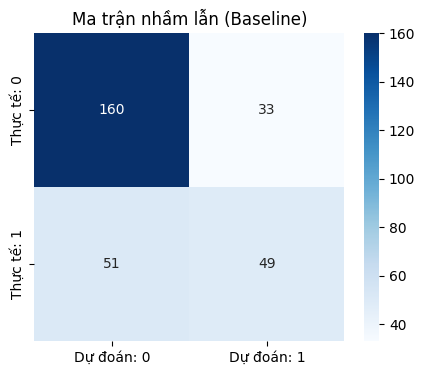

In [5]:
# ==========================================
# CELL 2: KIỂM TRA, VẼ BIỂU ĐỒ, LƯU METRIC VÀ NHẬN XÉT VÀO SRC/RESULTS
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd
import os

# Kiểm tra xem Cell 1 đã chạy thành công chưa
if 'df' not in locals():
    print("❌ LỖI: Biến 'df' chưa tồn tại. Bạn phải chạy Cell 1 thành công trước khi chạy Cell 2!")
else:
    print(f"Tổng số dòng (mẫu): {len(df)}")
    print(f"Tổng số cột (đặc trưng): {df.shape[1]}")
    print("-" * 30)

    # 1. Đặt Ngưỡng và tạo cột dự đoán
    THRESHOLD = 0.65 
    df['du_doan'] = (df['similarity_score'] >= THRESHOLD).astype(int)

    # 2. Chỉ định đường dẫn tới thư mục bằng đường dẫn tương đối
    thu_muc_luu = "../src/results"
    
    # exist_ok=True giúp không bị báo lỗi nếu thư mục đã có sẵn
    if not os.path.exists(thu_muc_luu):
        os.makedirs(thu_muc_luu, exist_ok=True)

    # ==========================================
    # LƯU 1: BẢNG METRIC (.csv)
    # ==========================================
    print("\n--- KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH BASELINE ---")
    report_text = classification_report(df['Label'], df['du_doan'])
    print(report_text)

    report_dict = classification_report(df['Label'], df['du_doan'], output_dict=True)
    df_metrics = pd.DataFrame(report_dict).transpose()
    csv_path = os.path.join(thu_muc_luu, "bang_metric_baseline.csv")
    df_metrics.to_csv(csv_path)
    print(f"✅ [1/3] Đã lưu bảng Metric vào: {csv_path}")

    # ==========================================
    # LƯU 2: BẢN TÓM TẮT & NHẬN XÉT (.txt)
    # ==========================================
    txt_path = os.path.join(thu_muc_luu, "nhan_xet_metric_baseline.txt")
    with open(txt_path, "w", encoding="utf-8") as f:
        f.write("BẢNG ĐÁNH GIÁ VÀ NHẬN XÉT MÔ HÌNH BASELINE (JACCARD)\n")
        f.write("="*55 + "\n\n")
        f.write(report_text + "\n")
        f.write("="*55 + "\n")
        f.write("NHẬN XÉT & KẾ HOẠCH:\n")
        f.write(f"1. Ngưỡng phân định (Threshold): Được thiết lập ở mức {THRESHOLD} dựa trên biểu đồ phân bố.\n")
        f.write("2. Đánh giá kết quả:\n")
        f.write("   - Mô hình có xu hướng nhận diện rất tốt các bài Tự làm (Lớp 0) do dữ liệu mất cân bằng.\n")
        f.write("   - Đối với Lớp 1 (Đạo văn), chỉ số F1-Score ở mức trung bình. Hệ thống bắt được các lỗi copy cơ bản nhưng vẫn còn tỷ lệ báo động giả (False Positive) và bỏ lọt đạo văn tinh vi (False Negative).\n")
        f.write("3. Kế hoạch Tuần 3:\n")
        f.write("   - Cải tiến hàm tiền xử lý: Bổ sung module ẩn danh hóa tên biến, tên hàm bằng thư viện 'ast'.\n")
        f.write("   - Nâng cấp thuật toán: Băm chuỗi bằng thuật toán Winnowing hoặc N-grams (k=3, k=5) để tăng độ chính xác.\n")
    print(f"✅ [2/3] Đã tạo và lưu file nhận xét tại: {txt_path}")

    # ==========================================
    # LƯU 3: MA TRẬN NHẦM LẪN (.png)
    # ==========================================
    plt.figure(figsize=(5, 4))
    cm = confusion_matrix(df['Label'], df['du_doan'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Dự đoán: 0', 'Dự đoán: 1'], 
                yticklabels=['Thực tế: 0', 'Thực tế: 1'])
    plt.title('Ma trận nhầm lẫn (Baseline)')
    
    png_path = os.path.join(thu_muc_luu, "confusion_matrix_baseline.png")
    plt.savefig(png_path, dpi=300, bbox_inches='tight')
    print(f"✅ [3/3] Đã lưu ảnh Ma trận nhầm lẫn vào: {png_path}")

    # Hiển thị biểu đồ lên màn hình
    plt.show()